<a href="https://colab.research.google.com/github/GerardoMunoz/axis/blob/main/Axis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# To Do
# Revisar que los tipos de objetos sean correctos en los constructores y demás argunetos
# En las operaciones de los Join devolver Join y añadir combinación lineal para ahorrar crear objetos intermedios, o crear vectores para esas operaciones


from IPython.display import SVG, display
import math
from math import cos, sin, tan, pi, sqrt, atan2, acos, asin
import ipywidgets as widgets


class Vec:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.xy = (self.x, self.y)

    def __getitem__(self, key):
        return self.xy[key]

    def __add__(self, other):
        return Vec(self[0]+other[0], self[1]+other[1])

    def __radd__(self, other):
        return Vec(self[0]+other[0], self[1]+other[1])

    def __sub__(self, other):
        return Vec(self[0]-other[0], self[1]-other[1])

    def __rsub__(self, other):
        return Vec(-self[0]+other[0], -self[1]+other[1])

    def __mul__(self, other):
        return Vec(self[0]*other, self[1]*other)

    def __rmul__(self, other):
        return Vec(self[0]*other, self[1]*other)

    def __div__(self, other):
        return Vec(self[0]/other, self[1]/other)

    @staticmethod
    def combLin( *listVec):
        """
        list of tuples of (escalar, vector)
        """
        x,y=0,0
        for vec in listVec:
            if isinstance(vec, tuple):
                escalar=vec[0]
                vec=vec[1]
            x+=vec[0]
            y+=vec[1]
        return Vec(x,y)


class Join_graph:
    def __init__(self, canvas,xy, label="",radius=5, color="gray", color_text="gray",font_size="16",move_text=(-10,-4),visible=True):
        self.canvas = canvas
        canvas.add(self)
        self.xy = xy
        self.label = label
        self.radius = radius
        self.color_point = color
        self.color_text = color_text
        self.font_size = font_size
        self.move_text = move_text
        self.visible=visible

    def get_svg(self):
        x, y = self.canvas.transform(self.xy)

        svg = f'\n<circle cx="{x}" cy="{y}" r="{self.radius}" fill="{self.color_point}" />'

        if self.label:
            svg += f'\n<text x="{x + 5}" y="{y - 5}" fill="{self.color_text}" font-size="{self.font_size}">{self.label}</text>'

        return svg
    # def get_svg(self):
    #     svg=""
    #     if self.visible:
    #         svg += f'\n<circle cx="{self.xy[0]}" cy="{self.xy[1]}" r="{self.radius}" fill="{self.color_point}" />'
    #     if self.label:
    #         svg += f'\n<text x="{self.xy[0] + self.move_text[0]}" y="{self.xy[1] + self.move_text[1]}" fill="{self.color_text}" font-size="{self.font_size}">{self.label}</text>'
    #     return svg

    def x(self):
        return self.xy[0]

    def y(self):
        return self.xy[1]

    def __getitem__(self, key):
        return self.xy[key]




class Link_graph:
    def __init__(self,canvas, P0, P1, label="", thickness=3, color="gray", color_text="gray",font_size="16",move_text=(-20,-5)):
        self.canvas = canvas
        canvas.add(self)
        self.P0 = P0
        self.P1 = P1
        self.label = label
        self.thickness = thickness
        self.color_line = color
        self.color_text = color_text
        self.font_size = font_size
        self.move_text = move_text


    def length(self):
        dx = self.P1[0] - self.P0[0]
        dy = self.P1[1] - self.P0[1]
        return math.sqrt(dx*dx + dy*dy)

    def get_svg(self):
        x1, y1 = self.canvas.transform(self.P0)
        x2, y2 = self.canvas.transform(self.P1)

        svg = f'\n<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="{self.color_line}" stroke-width="{self.thickness}"/>'
        I=self
        if I.label:
            # Calculate midpoint for the label
            mid_x = (x1+x2) / 2
            mid_y = (y1+y2) / 2
            svg += f'\n<text x="{mid_x+I.move_text[0]}" y="{mid_y + I.move_text[1]}" fill="{I.color_text}" font-size="{I.font_size}" >{I.label}</text>'#text-anchor="middle"

        return svg

    # def get_svg(I):#, x1, y1, x2, y2, stroke="white", stroke_width=2, label=""):
    #     svg = f'\n<line x1="{I.P0[0]}" y1="{I.P0[1]}" x2="{I.P1[0]}" y2="{I.P1[1]}" stroke="{I.color_line}" stroke-width="{I.thickness}"/>'
    #     if I.label:
    #         # Calculate midpoint for the label
    #         mid_x = (I.P0[0] + I.P1[0]) / 2
    #         mid_y = (I.P0[1] + I.P1[1]) / 2
    #         svg += f'\n<text x="{mid_x+I.move_text[0]}" y="{mid_y + I.move_text[1]}" fill="{I.color_text}" font-size="{I.font_size}" >{I.label}</text>'#text-anchor="middle"
    #     return svg


class Canvas:
    def __init__(I,width=512,height=256,background_color="black",):
        I.width = width
        I.height = height
        I.background_color = background_color
        I.elements = []

    def transform(self, xy):
        return xy

    def add(I,element):
        I.elements.append(element)

    def get_svg(I):
        svg=f"""
<svg width="{I.width}" height="{I.height}" viewBox="0 0 {I.width} {I.height}" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="100%" height="100%" fill="{I.background_color}" />
"""
        for element in I.elements:
            svg+=element.get_svg()
        svg+="""</svg>"""
        return svg


class Axis(Canvas):
    def __init__(self, width=512, height=256,
                 x_min=-1, y_min=-1, x_max=1, y_max=1,
                 background_color="black"):

        super().__init__(width, height, background_color)

        self.x_min = x_min
        self.y_min = y_min
        self.x_max = x_max
        self.y_max = y_max

        # Compute scale
        self.scale_x = width / (x_max - x_min)
        self.scale_y = height / (y_max - y_min)

    def transform(self, xy):
        """
        World → SVG coordinates
        """
        x=xy[0]
        y=xy[1]
        svg_x = (x - self.x_min) * self.scale_x
        svg_y = self.height - (y - self.y_min) * self.scale_y
        return (svg_x, svg_y)


class Angle_graph:
    def __init__(self, canvas, A, B, C, label="", radius=30, color="gray", thickness=2, colo_text="gray",font_size="14",label_d=(10,10)):
        self.canvas = canvas
        canvas.add(self)

        self.A = A
        self.B = B  # vertex
        self.C = C

        self.radius = radius
        self.label = label
        self.color = color
        self.thickness = thickness
        self.color_text = colo_text
        self.font_size = font_size
        self.label_d=label_d

    def normalize(self, vx, vy):
        norm = math.sqrt(vx*vx + vy*vy)
        return vx / norm, vy / norm

    def get_svg(self):

        A = self.canvas.transform(self.A)
        B = self.canvas.transform(self.B)
        C = self.canvas.transform(self.C)
        # Vectors BA and BC
        v1x, v1y = A[0] - B[0], A[1] - B[1]
        v2x, v2y = C[0] - B[0], C[1] - B[1]

        # Normalize
        n1x, n1y = self.normalize(v1x, v1y)
        n2x, n2y = self.normalize(v2x, v2y)


        start_x = B[0] + n1x * self.radius
        start_y = B[1] + n1y * self.radius

        end_x = B[0] + n2x * self.radius
        end_y = B[1] + n2y * self.radius

        # Determine direction using cross product
        cross = v1x * v2y - v1y * v2x
        sweep_flag = 1 if cross > 0 else 0

        # Always use small arc
        large_arc_flag = 0

        svg = f"""
<path d="
M {start_x} {start_y}
A {self.radius} {self.radius} 0 {large_arc_flag} {sweep_flag} {end_x} {end_y}
" stroke="{self.color}" fill="none" stroke-width="{self.thickness}"/>
"""

        # Label position (middle direction)
        mid_dx = n1x + n2x
        mid_dy = n1y + n2y
        mid_len = math.sqrt(mid_dx**2 + mid_dy**2)

        if mid_len != 0:
            mid_dx /= mid_len
            mid_dy /= mid_len

            label_x = B[0] + mid_dx * (self.radius + self.label_d[0])
            label_y = B[1] + mid_dy * (self.radius + self.label_d[1])

            if self.label:
                svg += f'\n<text x="{label_x}" y="{label_y}" fill="{self.color}" font-size="{self.font_size}">{self.label}</text>'

        return svg


def r2d(rad):
    return str(int(rad*180/pi))

def law_cos_rad(bc,ac,ab):
    return math.acos((ac**2+ab**2-bc**2)/(2*ac*ab))

def law_cos_deg(bc,ac,ab):
    return math.degrees(law_cos_rad(bc,ac,ab))



<svg width="512" height="256" viewBox="0 0 512 256" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="100%" height="100%" fill="white" />

<circle cx="20" cy="30" r="5" fill="gray" />
<text x="25" y="25" fill="gray" font-size="16">a</text>
<circle cx="200" cy="50" r="5" fill="gray" />
<text x="205" y="45" fill="gray" font-size="16">b</text>
<line x1="20" y1="30" x2="200" y2="50" stroke="gray" stroke-width="3"/>
<text x="90.0" y="35.0" fill="gray" font-size="16" >ab</text></svg>


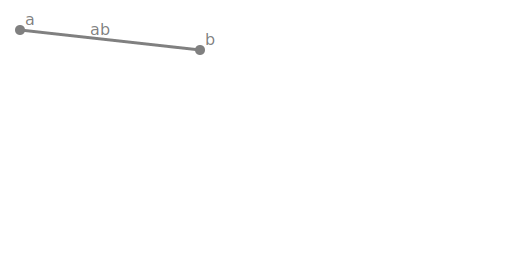

In [13]:

canvas=Canvas(background_color="white")
a=Join_graph(canvas,(20,30),'a')
b=Join_graph(canvas,(200,50),'b')
ab=Link_graph(canvas,a,b,'ab')
svg_code=canvas.get_svg()
print(svg_code)
# Display the SV
display(SVG(svg_code))




<svg width="512" height="256" viewBox="0 0 512 256" xmlns="http://www.w3.org/2000/svg">
  <!-- Background -->
  <rect width="100%" height="100%" fill="white" />

<circle cx="20" cy="30" r="5" fill="gray" />
<text x="25" y="25" fill="gray" font-size="16">a</text>
<circle cx="200" cy="50" r="5" fill="gray" />
<text x="205" y="45" fill="gray" font-size="16">b</text>
<line x1="20" y1="30" x2="200" y2="50" stroke="gray" stroke-width="3"/>
<text x="90.0" y="35.0" fill="gray" font-size="16" >ab</text>
<circle cx="30" cy="200" r="5" fill="gray" />
<text x="35" y="195" fill="gray" font-size="16">a</text>
<line x1="200" y1="50" x2="30" y2="200" stroke="gray" stroke-width="3"/>
<text x="95.0" y="120.0" fill="gray" font-size="16" >ac</text>
<path d="
M 177.50486433904723 69.84864911260539
A 30 30 0 0 1 170.18348795979142 46.68705421775461
" stroke="gray" fill="none" stroke-width="2"/>

<text x="161.86009402048762" y="62.05601807704173" fill="gray" font-size="14">alpha</text></svg>


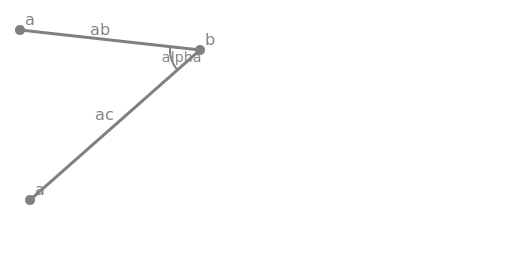

In [14]:


canvas=Canvas(background_color="white")
a1=Join_graph(canvas,(20,30),'a')
b1=Join_graph(canvas,(200,50),'b')
ab1=Link_graph(canvas,a1,b1,'ab')
c1=Join_graph(canvas,(30,200),'a')
ac1=Link_graph(canvas,b1,c1,'ac')
Angle_graph(canvas,c1,b1,a1,"alpha")
svg_code=canvas.get_svg()
print(svg_code)
# Display the SV
display(SVG(svg_code))

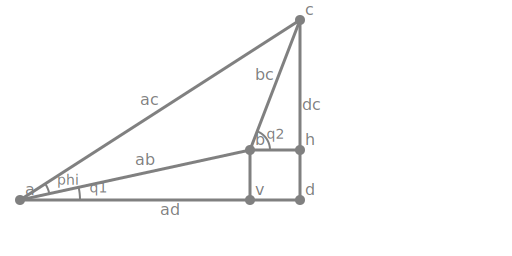

In [15]:
canvas=Canvas(background_color="white")
a=Join_graph(canvas,(20,200),'a')
b=Join_graph(canvas,(250,150),'b',move_text=(-8,-8))
c=Join_graph(canvas,(300,20),'c')
d=Join_graph(canvas,(300,200),'d ')
h=Join_graph(canvas,(300,150),'h')#,visible=False)
v=Join_graph(canvas,(250,200),'v')#,visible=False)
Link_graph(canvas,a,b,'ab',move_text=(0,-10))
Link_graph(canvas,a,c,'ac')
Link_graph(canvas,a,d,'ad',move_text=(0,15))
Link_graph(canvas,b,c,'bc')
Link_graph(canvas,b,h,'')
Link_graph(canvas,b,v,'')
Link_graph(canvas,d,c,'dc',move_text=(2,0))
Angle_graph(canvas,c,a,b,"phi")
Angle_graph(canvas,d,a,b,"q1",radius=60)
Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))
svg_code=canvas.get_svg()
#print(svg_code)
display(SVG(svg_code))

In [17]:

def update1(c_x):
    canvas1=Axis(width=512,height=512, x_min = 0, y_min = 0, x_max = 512, y_max = 256,background_color="white")
    a1=Join_graph(canvas1,(20,200),'a')
    b1=Join_graph(canvas1,(250,150),'b',move_text=(-8,-8))
    c1=Join_graph(canvas1,(c_x,20),'c')
    ab1=Link_graph(canvas1,a1,b1,'ab',move_text=(0,-10))
    ac1=Link_graph(canvas1,a1,c1,'ac')
    bc1=Link_graph(canvas1,b1,c1,'bc')
    angle=law_cos_deg(bc1.length(),ac1.length(),ab1.length())
    print(bc1.length(),ac1.length(),ab1.length(),angle)
    Angle_graph(canvas1,c1,a1,b1,"phi="+str(int(angle)))
    svg_code=canvas1.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update1, c_x=(10, 400, 1))
#display(SVG(svg_code))

interactive(children=(IntSlider(value=205, description='c_x', max=400, min=10), Output()), _dom_classes=('widg…

<function __main__.update1(c_x)>

In [18]:
def update3(q1_deg,q2_deg):
    q1=q1_deg*pi/180
    q2=q2_deg*pi/180
    canvas=Axis(width=512,height=400, x_min = 0, y_min = 0, x_max = 512, y_max = 400,background_color="white")
    ab_length=300
    bc_length=200
    a_x=20
    a_y=20
    b_x=ab_length*cos(q1)
    b_y=ab_length*sin(q1)
    c_x=b_x+bc_length*cos(q2)
    c_y=b_y+bc_length*sin(q2)
    #print(int(a_x),int(a_y),int(b_x),int(b_y),int(c_x),int(c_y))

    a=Join_graph(canvas,(a_x,a_y),'a')
    b=Join_graph(canvas,(b_x,b_y),'b',move_text=(-8,-8))
    c=Join_graph(canvas,(c_x,c_y),'c')
    #d=Join_graph(canvas,(c_x,a_y),'d ')
    h=Join_graph(canvas,(c_x,b_y),'h')#,visible=False)
    v=Join_graph(canvas,(b_x,a_y),'v')#,visible=False)

    ab=Link_graph(canvas,a,b,'ab')#,move_text=(0,-10))
    ac=Link_graph(canvas,a,c,'ac')
    Link_graph(canvas,a,v,'')#,move_text=(0,15))
    #Link_graph(canvas,v,d,'')#,move_text=(0,15))
    bc=Link_graph(canvas,b,c,'bc')
    Link_graph(canvas,b,h,'')
    #Link_graph(canvas,b,v,'ab sin(q1)')
    #Link_graph(canvas,d,h,'')#,move_text=(2,0))
    #Link_graph(canvas,h,c,'bc sin(q2)')#,move_text=(2,0))
    angle=law_cos_deg(bc.length(),ac.length(),ab.length())
    print('phi='+str(int(angle)))
    Angle_graph(canvas,c,a,b,"phi="+str(int(angle)))
    Angle_graph(canvas,v,a,b,"q1",radius=60)
    Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))
    svg_code=canvas.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update3, q1_deg=(10, 40, 1), q2_deg=(-10, 85, 1))

interactive(children=(IntSlider(value=25, description='q1_deg', max=40, min=10), IntSlider(value=37, descripti…

<function __main__.update3(q1_deg, q2_deg)>

# Law of cosines

If a triangle has vertices $a,b,c$ and the length of the segments are $ab, ac,bc$ and $phi$ is the angle between ab and ac, then:

#$$phi=\cos^{-1}\left(\frac{ac^2+ab^2-bc^2}{2(ac)(ab)}\right)$$

#$$bc^2 = ac^2+ab^2 -2(ac)(ab)\cos(phi)$$

In [23]:
def update4(q1_deg,q2_deg):
    q1=q1_deg*pi/180
    q2=q2_deg*pi/180
    canvas=Axis(width=1000,height=400, x_min = 0, y_min = 0, x_max = 1000, y_max = 400,background_color="white")
    ab_length=300
    bc_length=200
    a_x=20
    a_y=20
    b_x=a_x+ab_length*cos(q1)
    b_y=a_y+ab_length*sin(q1)
    c_x=b_x+bc_length*cos(q2)
    c_y=b_y+bc_length*sin(q2)
    #print(int(a_x),int(a_y),int(b_x),int(b_y),int(c_x),int(c_y))

    a=Join_graph(canvas,(a_x,a_y),'a')
    b=Join_graph(canvas,(b_x,b_y),'b',move_text=(-8,-8))
    c=Join_graph(canvas,(c_x,c_y),'c')
    #d=Join_graph(canvas,(c_x,a_y),'d ')
    h=Join_graph(canvas,(c_x,b_y),'h')#,visible=False)
    v=Join_graph(canvas,(b_x,a_y),'v')#,visible=False)

    Link_graph(canvas,a,b,'l1')#,move_text=(0,-10))
    Link_graph(canvas,a,c,'')
    Link_graph(canvas,a,v,'')#l1 cos(q1)='+str(int(b_x-a_x)))#,move_text=(0,15))
    #Link_graph(canvas,v,d,'')#,move_text=(0,15))
    Link_graph(canvas,b,c,'l2')
    Link_graph(canvas,b,h,'')#l2 cos(q2)='+str(int(c_x-b_x)))
    #Link_graph(canvas,b,v,'l1 sin(q1)='+str(int(b_y-a_y)),move_text=(10,0))
    #Link_graph(canvas,d,h,'')#,move_text=(2,0))
    #Link_graph(canvas,h,c,'l2 sin(q2)='+str(int(c_y-b_y)),move_text=(10,0))#,move_text=(2,0))

    #Angle_graph(canvas,c,a,b,"phi")
    Angle_graph(canvas,v,a,b,"q1",radius=60)
    Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))

    a1_x=520
    a1_y=20
    c1_x=c_x-a_x+a1_x
    c1_y=c_y-a_y+a1_y
    #v_ab=Vec.combLin([(a_x,a),()]ab_length,Vec(cos(q1),sin(q1)))
    ac_length=sqrt((c_x-a_x)**2+(c_y-a_y)**2)
    ae_length=(ab_length**2 + ac_length**2 -bc_length**2)/(2*ac_length)
    e1_x = a1_x + ae_length/ac_length*(c_x-a_x)
    e1_y = a1_y + ae_length/ac_length*(c_y-a_y)
    eb_length=sqrt((ab_length)**2-(ae_length)**2)
    b1_x=e1_x+eb_length/ac_length*(c1_y-a1_y)
    b1_y=e1_y+eb_length/ac_length*(-(c1_x-a1_x))
    b1p_x=e1_x-eb_length/ac_length*(c1_y-a1_y)
    b1p_y=e1_y-eb_length/ac_length*(-(c1_x-a1_x))

    print('error:',int((b1_x-a1_x)-(b_x-a_x)),int((b1_y-a1_y)-(b_y-a_y)))
    print('error:',int((b1p_x-a1_x)-(b_x-a_x)),int((b1p_y-a1_y)-(b_y-a_y)))



    a1=Join_graph(canvas,(a1_x,a1_y),'a')
    b1=Join_graph(canvas,(b1_x,b1_y),'b',move_text=(-8,-8))
    b1p=Join_graph(canvas,(b1p_x,b1p_y),'bp',move_text=(-8,-8))
    c1=Join_graph(canvas,(c1_x,c1_y),'c')
    #d1=Join_graph(canvas,(c1_x,a1_y),'d ')
    #h1=Join_graph(canvas,(c1_x,b1_y),'h')#,visible=False)
    #v1=Join_graph(canvas,(b1_x,a1_y),'v')#,visible=False)
    e1=Join_graph(canvas,(e1_x,e1_y),'e')


    Link_graph(canvas,a1,b1,'l1')#,move_text=(0,-10))
    Link_graph(canvas,a1,c1,'ac')
    #Link_graph(canvas,a1,v1,'')#l1 cos(q1)='+str(int(b1_x-a1_x)))#,move_text=(0,15))
    #Link_graph(canvas,v1,d1,'')#,move_text=(0,15))
    Link_graph(canvas,b1,c1,'l2')
    #Link_graph(canvas,b1,h1,'')#l2 cos(q2)='+str(int(c1_x-b1_x)))
    #Link_graph(canvas,b1,v1,'')#l1 sin(q1)='+str(int(b1_y-a1_y)),move_text=(10,0))
    #Link_graph(canvas,d1,h1,'')#,move_text=(2,0))
    #Link_graph(canvas,h1,c1,'')#l2 sin(q2)='+str(int(c1_y-b1_y)),move_text=(10,0))#,move_text=(2,0))
    Link_graph(canvas,e1,b1,'')
    Link_graph(canvas,e1,b1p,'')

    #Angle_graph(canvas,c1,a1,b1,"phi1="+r2d(phi1))
    #Angle_graph(canvas,c1,a1,d1,"phi2="+r2d(phi2),radius=80)
    #Angle_graph(canvas,v1,a1,b1,"qq1",radius=60)
    #Angle_graph(canvas,h1,b1,c1,"qq2",radius=20,label_d=(0,0))






    svg_code=canvas.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update4, q1_deg=(10, 40, 1), q2_deg=(-20, 85, 1))

interactive(children=(IntSlider(value=25, description='q1_deg', max=40, min=10), IntSlider(value=32, descripti…

<function __main__.update4(q1_deg, q2_deg)>

# Finding Point R in a Triangle from Two Known Points and Side Lengths

## Problem Overview

Given:

* Two known points **P** and **Q** in the plane
* The distances **|PR|** and **|QR|**

Goal:

* Find the coordinates of the third point **R**

This is a classic geometric problem that can be solved using vector projections and the Law of Cosines.

---

## Step 1: Define Vectors

Let:

* **P = (Px, Py)**
* **Q = (Qx, Qy)**

Define the vector:

```
PQ = Q - P
```

Compute its magnitude:

```
|PQ| = d
```

---

## Step 2: Find the Projection Point S

We want to find point **S**, which is the projection of **R** onto the line defined by **PQ**.

Using the Law of Cosines on triangle PQR:

```
|QR|^2 = |PQ|^2 + |PR|^2 - 2|PQ||PR| cos(theta)
```

Solve for the projection distance **|PS|**:

```
|PS| = (|PR|^2 + |PQ|^2 - |QR|^2) / (2|PQ|)
```

Now compute point S:

```
S = P + (|PS| / |PQ|) * (PQ)
```

---

## Step 3: Compute the Perpendicular Distance |SR|

Using the Pythagorean relation:

```
|SR| = sqrt(|PR|^2 - |PS|^2)
```

---

## Step 4: Find a Perpendicular Vector

Let **PQ = (dx, dy)**.

A perpendicular vector is:

```
v_perp = (-dy, dx)
```

Normalize it:

```
v_unit = v_perp / |PQ|
```

Scale it to length |SR|:

```
v = |SR| * v_unit
```

---

## Step 5: Compute Point R

There are two possible solutions (above and below the line PQ):

```
R = S + v
```

or

```
R = S - v
```

---

## Final Result

The point(s) R are given by:

```
R = S ± v
```

Where:

* S is the projection of R onto PQ
* v is a perpendicular vector of magnitude |SR|

---

## Notes

* This method yields two symmetric solutions unless additional constraints are given.
* The approach works in 2D Cartesian coordinates.
* In 3D, additional information would be needed to uniquely determine R.

---

## Summary

1. Compute vector PQ and its magnitude
2. Use Law of Cosines to find projection distance |PS|
3. Compute projection point S
4. Compute perpendicular distance |SR|
5. Build perpendicular vector v
6. Compute R = S ± v

---

## Optional: Compact Formula

```
Let u = (Q - P)/|PQ|
Let v = perpendicular unit vector to u

S = P + u * ((|PR|^2 + |PQ|^2 - |QR|^2) / (2|PQ|))
R = S ± v * sqrt(|PR|^2 - |PS|^2)
```

---

End of presentation


# Two-Link Planar Robotic Arm

A simple model of a planar robotic arm composed of two segments: **upper arm** and **forearm**. This system is commonly used in robotics to illustrate basic kinematic concepts.

## System Description

The robotic arm consists of:

* A first segment (upper arm) with length **l1**
* A second segment (forearm) with length **l2**

Both segments are connected through rotational joints.

## Model Variables

* **q1**: Angle of the upper arm measured from the horizontal
* **q2**: Angle of the forearm measured from the horizontal
* **l1**: Length of the upper arm
* **l2**: Length of the forearm

> Note: Both angles are measured with respect to the horizontal axis.



In [19]:
def update2(q1_deg,q2_deg):
    q1=q1_deg*pi/180
    q2=q2_deg*pi/180
    canvas=Axis(width=600,height=400, x_min = 0, y_min = 0, x_max = 600, y_max = 400,background_color="white")
    ab_length=300
    bc_length=200
    a_x=20
    a_y=20
    b_x=ab_length*cos(q1)
    b_y=ab_length*sin(q1)
    c_x=b_x+bc_length*cos(q2)
    c_y=b_y+bc_length*sin(q2)
    #print(int(a_x),int(a_y),int(b_x),int(b_y),int(c_x),int(c_y))

    a=Join_graph(canvas,(a_x,a_y),'a')
    b=Join_graph(canvas,(b_x,b_y),'b',move_text=(-8,-8))
    c=Join_graph(canvas,(c_x,c_y),'c')
    #d=Join_graph(canvas,(c_x,a_y),'d ')
    h=Join_graph(canvas,(c_x,b_y),'h')#,visible=False)
    v=Join_graph(canvas,(b_x,a_y),'v')#,visible=False)

    Link_graph(canvas,a,b,'l1')#,move_text=(0,-10))
    #Link_graph(canvas,a,c,'')
    Link_graph(canvas,a,v,'l1 cos(q1)='+str(int(b_x-a_x)))#,move_text=(0,15))
    #Link_graph(canvas,v,d,'')#,move_text=(0,15))
    Link_graph(canvas,b,c,'l2')
    Link_graph(canvas,b,h,'l2 cos(q2)='+str(int(c_x-b_x)))
    Link_graph(canvas,b,v,'l1 sin(q1)='+str(int(b_y-a_y)),move_text=(10,0))
    #Link_graph(canvas,d,h,'')#,move_text=(2,0))
    Link_graph(canvas,h,c,'l2 sin(q2)='+str(int(c_y-b_y)),move_text=(10,0))#,move_text=(2,0))

    #Angle_graph(canvas,c,a,b,"phi")
    Angle_graph(canvas,v,a,b,"q1",radius=60)
    Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))
    svg_code=canvas.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update2, q1_deg=(10, 40, 1), q2_deg=(-10, 85, 1))

interactive(children=(IntSlider(value=25, description='q1_deg', max=40, min=10), IntSlider(value=37, descripti…

<function __main__.update2(q1_deg, q2_deg)>

## Forward Kinematics

The position of the end-effector in the Cartesian plane $\begin{bmatrix}
c_x \\
c_y
\end{bmatrix}$ is given by:

$$ b_x = l_1 \cos(q_1))
\\ b_y = l_1 \sin(q_1))$$


$$ c_x = b_x + l_2 \cos(q_2)) = l_1 \cos(q_1)) + l_2 \cos(q_2)) \\
 c_y = b_y + l_2 \sin(q_2)) = l_1 \sin(q_1)) + l_2 \sin(q_2))$$


$$\begin{bmatrix}
c_x \\
c_y
\end{bmatrix}
=
\begin{bmatrix}
\cos(q_1) & \cos(q_2) \\
\sin(q_1) & \sin(q_2)
\end{bmatrix}
\begin{bmatrix}
l_1 \\
l_2
\end{bmatrix}$$

It is not the standard serial 2-link manipulator model.
* The first term represents the contribution of the upper arm.
* The second term represents the contribution of the forearm.
* The sum determines the final position of the end-effector.
* Both angles $q_1$ and $q_2$ are measured from the global horizontal
* Each link contributes independently to the end-effector position
* Absolute angle parameterization or a parallel / decoupled link representation



In [47]:
def update4(q1_deg,q2_deg):
    q1=q1_deg*pi/180
    q2=q2_deg*pi/180
    canvas=Axis(width=1000,height=400, x_min = 0, y_min = 0, x_max = 1000, y_max = 400,background_color="white")
    ab_length=300
    bc_length=200
    a_x=20
    a_y=20
    b_x=a_x+ab_length*cos(q1)
    b_y=a_y+ab_length*sin(q1)
    c_x=b_x+bc_length*cos(q2)
    c_y=b_y+bc_length*sin(q2)
    #print(int(a_x),int(a_y),int(b_x),int(b_y),int(c_x),int(c_y))

    a=Join_graph(canvas,(a_x,a_y),'a')
    b=Join_graph(canvas,(b_x,b_y),'b',move_text=(-8,-8))
    c=Join_graph(canvas,(c_x,c_y),'c')
    #d=Join_graph(canvas,(c_x,a_y),'d ')
    h=Join_graph(canvas,(c_x,b_y),'h')#,visible=False)
    v=Join_graph(canvas,(b_x,a_y),'v')#,visible=False)

    Link_graph(canvas,a,b,'l1')#,move_text=(0,-10))
    #Link_graph(canvas,a,c,'')
    Link_graph(canvas,a,v,'l1 cos(q1)='+str(int(b_x-a_x)))#,move_text=(0,15))
    #Link_graph(canvas,v,d,'')#,move_text=(0,15))
    Link_graph(canvas,b,c,'l2')
    Link_graph(canvas,b,h,'l2 cos(q2)='+str(int(c_x-b_x)))
    Link_graph(canvas,b,v,'l1 sin(q1)='+str(int(b_y-a_y)),move_text=(10,0))
    #Link_graph(canvas,d,h,'')#,move_text=(2,0))
    Link_graph(canvas,h,c,'l2 sin(q2)='+str(int(c_y-b_y)),move_text=(10,0))#,move_text=(2,0))

    #Angle_graph(canvas,c,a,b,"phi")
    Angle_graph(canvas,v,a,b,"q1",radius=60)
    Angle_graph(canvas,h,b,c,"q2",radius=20,label_d=(0,0))

    ac_length=sqrt((c_x-a_x)**2+(c_y-a_y)**2)
    phi1=law_cos_rad(bc_length,ab_length,ac_length)
    phi2=atan2(c_y-a_y,c_x-a_x)

    #print('phi='+str(int(phi1))+'phi='+str(int(phi1)))

    qq1=phi2-phi1
    print('c_x-ab_length*cos(qq1) / bc_length',c_x,a_x,ab_length*cos(qq1) , bc_length,c_x-a_x-ab_length*cos(qq1) / bc_length)
    qq2=acos((c_x-a_x-ab_length*cos(qq1)) / bc_length)

    a1_x=520
    a1_y=20
    b1_x=a1_x+ab_length*cos(qq1)
    b1_y=a1_y+ab_length*sin(qq1)
    c1_x=b1_x+bc_length*cos(qq2)
    c1_y=b1_y+bc_length*sin(qq2)
    #print(int(a_x),int(a_y),int(b_x),int(b_y),int(c_x),int(c_y))

    a1=Join_graph(canvas,(a1_x,a1_y),'a')
    b1=Join_graph(canvas,(b1_x,b1_y),'b',move_text=(-8,-8))
    c1=Join_graph(canvas,(c1_x,c1_y),'c')
    d1=Join_graph(canvas,(c1_x,a1_y),'d ')
    h1=Join_graph(canvas,(c1_x,b1_y),'h')#,visible=False)
    v1=Join_graph(canvas,(b1_x,a1_y),'v')#,visible=False)

    Link_graph(canvas,a1,b1,'l1')#,move_text=(0,-10))
    Link_graph(canvas,a1,c1,'ac')
    Link_graph(canvas,a1,v1,'')#l1 cos(q1)='+str(int(b1_x-a1_x)))#,move_text=(0,15))
    Link_graph(canvas,v1,d1,'')#,move_text=(0,15))
    Link_graph(canvas,b1,c1,'l2')
    Link_graph(canvas,b1,h1,'')#l2 cos(q2)='+str(int(c1_x-b1_x)))
    Link_graph(canvas,b1,v1,'')#l1 sin(q1)='+str(int(b1_y-a1_y)),move_text=(10,0))
    Link_graph(canvas,d1,h1,'')#,move_text=(2,0))
    Link_graph(canvas,h1,c1,'')#l2 sin(q2)='+str(int(c1_y-b1_y)),move_text=(10,0))#,move_text=(2,0))

    Angle_graph(canvas,c1,a1,b1,"phi1="+r2d(phi1))
    Angle_graph(canvas,c1,a1,d1,"phi2="+r2d(phi2),radius=80)
    Angle_graph(canvas,v1,a1,b1,"qq1",radius=60)
    Angle_graph(canvas,h1,b1,c1,"qq2",radius=20,label_d=(0,0))






    svg_code=canvas.get_svg()
    return SVG(svg_code)
#print(svg_code)
widgets.interact(update4, q1_deg=(10, 40, 1), q2_deg=(-10, 85, 1))

interactive(children=(IntSlider(value=25, description='q1_deg', max=40, min=10), IntSlider(value=37, descripti…

<function __main__.update4(q1_deg, q2_deg)>

# Inverse Kinematics


## Given

We assume three points:

* **a (a_x, a_y)**: base of the arm
* **b**: joint between links
* **c (c_x, c_y)**: desired end-effector position

And link lengths:

* **ab_length = l1** (upper arm)
* **bc_length = l2** (forearm)

---

## Law of Cosines Function

The following function computes an angle using the law of cosines:

```python
def law_cos_rad(bc, ac, ab):
    return math.acos((ac**2 + ab**2 - bc**2) / (2 * ac * ab))
```

---

## Step 1: Distance to Target

Compute the distance from base to target:

```python
ac_length = sqrt((c_x - a_x)**2 + (c_y - a_y)**2)
```

This represents the straight-line distance from the base to the end-effector.

---

## Step 2: Compute Intermediate Angles

### Angle from geometry (law of cosines)

```python
phi1 = law_cos_rad(bc_length, ab_length, ac_length)
```

### Angle to the target point

```python
phi2 = atan2(c_y - a_y, c_x - a_x)
```

---

## Step 3: Solve for q1

```python
qq1 = phi2 - phi1
```

* **phi2** gives the direction to the target
* **phi1** corrects for the triangle geometry
* Result: angle of the first joint

---

## Step 4: Solve for q2

```python
qq2 = acos((c_x - a_x - ab_length * cos(qq1)) / bc_length)
```

This computes the second joint angle based on the remaining horizontal projection.

